# Diabetes Risk Classifier — KNN From Scratch vs scikit-learn

This notebook walks through:
1. Loading & exploring the Pima Indians Diabetes dataset
2. Handling a real data quality issue: missing values encoded as 0
3. K-Nearest Neighbors implemented from scratch
4. Selecting K via from-scratch cross-validation
5. Benchmarking against scikit-learn's KNeighborsClassifier
6. Visualizing the bias-variance tradeoff and the KNN mechanism in 3D


In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_data, clean_missing_values, get_train_test_split, check_data_quality, ZERO_AS_MISSING_COLS
from knn_scratch import KNNClassifierScratch, cross_validate_k
from evaluate import full_report, print_report
from sklearn.neighbors import KNeighborsClassifier as SklearnKNN

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110


## 1. Load & Inspect the Data

In [2]:
df = load_data('../data/diabetes.csv')
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
report = check_data_quality(df)
for k, v in report.items():
    print(f"{k}: {v}")


n_rows: 768
n_cols: 9
duplicate_rows: 0
true_missing_values: 0
encoded_zero_missing__Glucose: 5 (0.7%)
encoded_zero_missing__BloodPressure: 35 (4.6%)
encoded_zero_missing__SkinThickness: 227 (29.6%)
encoded_zero_missing__Insulin: 374 (48.7%)
encoded_zero_missing__BMI: 11 (1.4%)


## 2. The Missing-Value Problem

`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` use **0 to represent a missing
measurement** (a blood pressure of 0 is not real). `Insulin` is missing in nearly half the dataset.
We clean this by converting these zeros to NaN, then impute using only the training set's median.


In [4]:
df_clean = clean_missing_values(df)
for col in ZERO_AS_MISSING_COLS:
    print(f"{col}: {df_clean[col].isnull().sum()} missing ({100*df_clean[col].isnull().mean():.1f}%)")


Glucose: 5 missing (0.7%)
BloodPressure: 35 missing (4.6%)
SkinThickness: 227 missing (29.6%)
Insulin: 374 missing (48.7%)
BMI: 11 missing (1.4%)


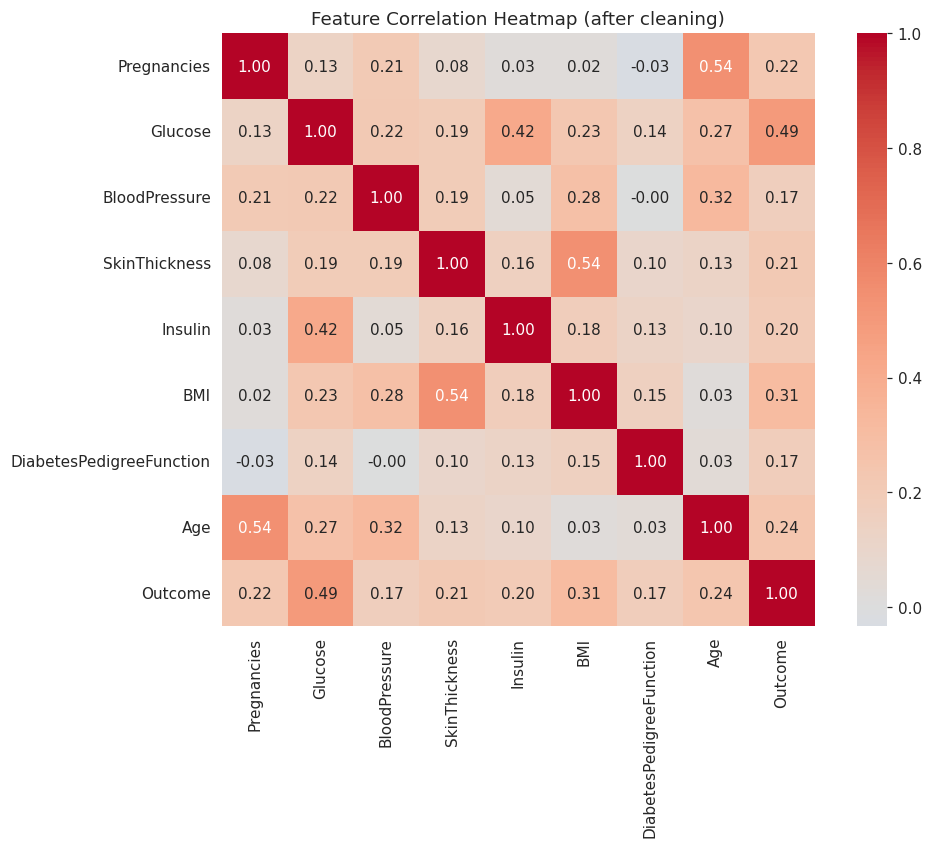

In [5]:
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(df_clean.fillna(df_clean.median()).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap (after cleaning)')
plt.show()


## 3. Preprocessing

80/20 stratified split. Missing values imputed using **training-set medians only** (no leakage).
Features standardized — critical for KNN since it's distance-based.


In [6]:
X_train, X_test, y_train, y_test, feature_names, scaler, medians = get_train_test_split(df)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train target rate:", y_train.mean().round(3), " Test target rate:", y_test.mean().round(3))


Train: (614, 8)  Test: (154, 8)
Train target rate: 0.349  Test target rate: 0.351


## 4. KNN From Scratch

**Prediction rule:** find the K closest training points (Euclidean distance), predict the majority class.

```
d(x, x') = sqrt( Σ (x_i - x'_i)² )
```

No traditional training — `fit()` just stores the data; all work happens at prediction time.


In [7]:
k_candidates = [1, 3, 5, 7, 9, 11, 13, 15, 19, 25]
cv_results = cross_validate_k(X_train, y_train, k_candidates, n_folds=5)
for k, acc in cv_results.items():
    print(f"k={k:2d} | mean CV accuracy = {acc:.4f}")

best_k = max(cv_results, key=cv_results.get)
print(f"\nBest K: {best_k}")


k= 1 | mean CV accuracy = 0.6952
k= 3 | mean CV accuracy = 0.7428
k= 5 | mean CV accuracy = 0.7410
k= 7 | mean CV accuracy = 0.7493
k= 9 | mean CV accuracy = 0.7574
k=11 | mean CV accuracy = 0.7672
k=13 | mean CV accuracy = 0.7657
k=15 | mean CV accuracy = 0.7625
k=19 | mean CV accuracy = 0.7672
k=25 | mean CV accuracy = 0.7722

Best K: 25


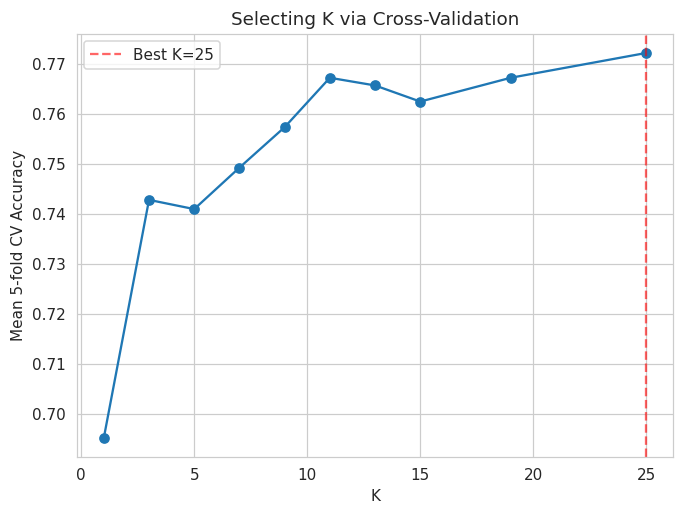

In [8]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(list(cv_results.keys()), list(cv_results.values()), marker='o')
ax.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
ax.set_xlabel('K')
ax.set_ylabel('Mean 5-fold CV Accuracy')
ax.set_title('Selecting K via Cross-Validation')
ax.legend()
plt.show()


## 5. The Bias-Variance Tradeoff

At K=1, every point is its own nearest neighbor — perfect training accuracy, but poor generalization.


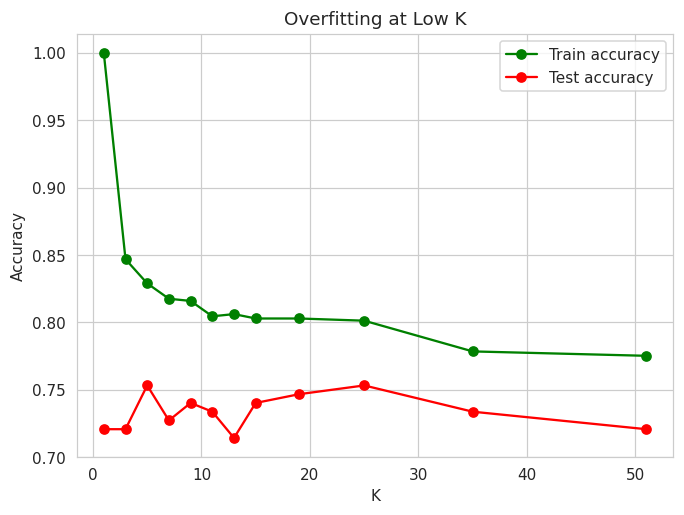

K=1:  train=1.0000  test=0.7208  gap=0.2792
K=25: train=0.8013  test=0.7532  gap=0.0481


In [9]:
k_range = [1, 3, 5, 7, 9, 11, 13, 15, 19, 25, 35, 51]
train_accs, test_accs = [], []
for k in k_range:
    m = KNNClassifierScratch(k=k)
    m.fit(X_train, y_train)
    train_accs.append(np.mean(m.predict(X_train) == y_train))
    test_accs.append(np.mean(m.predict(X_test) == y_test))

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(k_range, train_accs, marker='o', label='Train accuracy', color='green')
ax.plot(k_range, test_accs, marker='o', label='Test accuracy', color='red')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.set_title('Overfitting at Low K')
ax.legend()
plt.show()

print(f"K=1:  train={train_accs[0]:.4f}  test={test_accs[0]:.4f}  gap={train_accs[0]-test_accs[0]:.4f}")
print(f"K={best_k}: train={train_accs[k_range.index(best_k)]:.4f}  test={test_accs[k_range.index(best_k)]:.4f}  gap={train_accs[k_range.index(best_k)]-test_accs[k_range.index(best_k)]:.4f}")


## 6. Final Model vs scikit-learn

In [10]:
model = KNNClassifierScratch(k=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)
report_scratch = full_report(y_test, y_pred, y_scores, label=f"KNN (k={best_k}, scratch)")
print_report(report_scratch)

print()
sk_model = SklearnKNN(n_neighbors=best_k)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
sk_scores = sk_model.predict_proba(X_test)[:, 1]
report_sklearn = full_report(y_test, sk_pred, sk_scores, label=f"KNN (k={best_k}, sklearn)")
print_report(report_sklearn)


--- KNN (k=25, scratch) ---
  Accuracy : 0.7532
  Precision: 0.6818
  Recall   : 0.5556
  F1 Score : 0.6122
  ROC-AUC  : 0.8147
  Confusion: TP=30 TN=86 FP=14 FN=24

--- KNN (k=25, sklearn) ---
  Accuracy : 0.7532
  Precision: 0.6818
  Recall   : 0.5556
  F1 Score : 0.6122
  ROC-AUC  : 0.8147
  Confusion: TP=30 TN=86 FP=14 FN=24


## 7. 3D Visualization: The KNN Mechanism

A query point and its K nearest neighbors in Glucose × BMI × Age space.


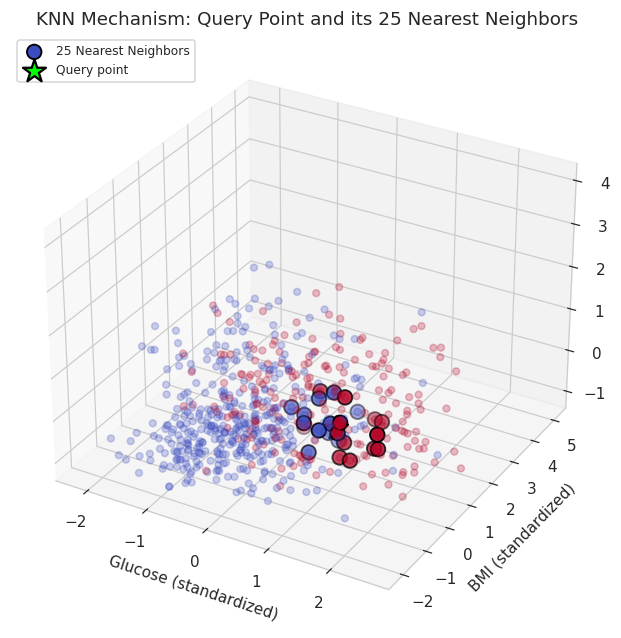

In [11]:
from mpl_toolkits.mplot3d import Axes3D

idx_glucose = feature_names.index('Glucose')
idx_bmi = feature_names.index('BMI')
idx_age = feature_names.index('Age')
X_vis = X_train[:, [idx_glucose, idx_bmi, idx_age]]

rng = np.random.RandomState(7)
query_idx = rng.choice(len(X_vis))
query_point = X_vis[query_idx]
distances = np.sqrt(np.sum((X_vis - query_point)**2, axis=1))
k_nearest_idx = np.argsort(distances)[:best_k+1]
k_nearest_idx = k_nearest_idx[k_nearest_idx != query_idx][:best_k]

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_vis[:,0], X_vis[:,1], X_vis[:,2], c=y_train, cmap='coolwarm', s=20, alpha=0.25)
ax.scatter(X_vis[k_nearest_idx,0], X_vis[k_nearest_idx,1], X_vis[k_nearest_idx,2],
           c=y_train[k_nearest_idx], cmap='coolwarm', s=90, edgecolor='black', linewidth=1.2, label=f'{best_k} Nearest Neighbors')
ax.scatter(*query_point, c='lime', s=250, marker='*', edgecolor='black', linewidth=1.5, label='Query point')
ax.set_xlabel('Glucose (standardized)')
ax.set_ylabel('BMI (standardized)')
ax.set_zlabel('Age (standardized)')
ax.set_title(f'KNN Mechanism: Query Point and its {best_k} Nearest Neighbors')
ax.legend(loc='upper left', fontsize=8)
plt.show()


## 8. Conclusion

- From-scratch KNN matches sklearn's `KNeighborsClassifier` exactly on every metric — confirms correctness.
- K=1 demonstrates pure memorization (100% train accuracy) with worse generalization than properly tuned K.
- **Recall (~56%) is the honest weak point** — this dataset's class imbalance and KNN's majority-vote bias toward
  the majority class mean a meaningful fraction of diabetic patients are missed. See `reports/report.md` for
  full discussion and limitations.
- This is an educational/portfolio project, not a validated screening tool.
